## Práctica Desempeño: Implementación del algoritmo Naive Bayes (Gaussian Naive Bayes)

## Dataset: Wine (incluido en scikit-learn)

**Carga del dataset**

from sklearn.datasets import load_wine

# Contexto del Problema

El dataset Wine contiene el resultado de un análisis químico de vinos cultivados en la misma región de Italia, pero provenientes de **tres cultivos distintos**.

Cada registro describe un vino mediante 13 mediciones químicas (alcohol, magnesio, flavonoides, etc.). El objetivo será construir un modelo capaz de predecir a cuál de los tres cultivos pertenece un vino a partir de esas mediciones:

- class_0
- class_1
- class_2

El interés práctico de este problema es evidente en el sector vitivinícola: contar con un modelo que, a partir de un análisis de laboratorio, prediga el origen o cultivo de un vino permite automatizar controles de calidad, detectar posibles mezclas o etiquetados incorrectos, y apoyar decisiones de clasificación cuando el origen no es evidente a simple vista.



In [1]:
#Importamos librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
accuracy_score,
confusion_matrix,
classification_report,
ConfusionMatrixDisplay
)
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
#Cargamos el dataset Wine
from sklearn.datasets import load_wine
wine = load_wine(as_frame = True)


In [3]:
print (wine.DESCR)


.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
dfWine = wine.frame
dfWine.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Exploracion del conjunto de datos


In [5]:
dfWine.shape


(178, 14)

In [6]:
dfWine.columns


Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [7]:
dfWine.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [8]:
dfWine.describe()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [9]:
wine.target_names


array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [10]:
#Verificamos valores nulos
dfWine.isnull().sum()


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [11]:
### Renombrar la columna "target"

dfWine.rename(columns = {"target" : "cultivo"}, inplace = True)


In [12]:
dfWine["cultivo"] = dfWine["cultivo"].map({
    0: "class_0",
    1: "class_1",
    2: "class_2"
})


In [13]:
dfWine.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivo
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [14]:
dfWine.tail()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivo
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740.0,class_2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750.0,class_2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835.0,class_2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840.0,class_2
177,14.13,4.10,2.74,24.5,96.0,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560.0,class_2


In [15]:
#Distribucion de la variable objetivo
dfWine["cultivo"].value_counts()


cultivo
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

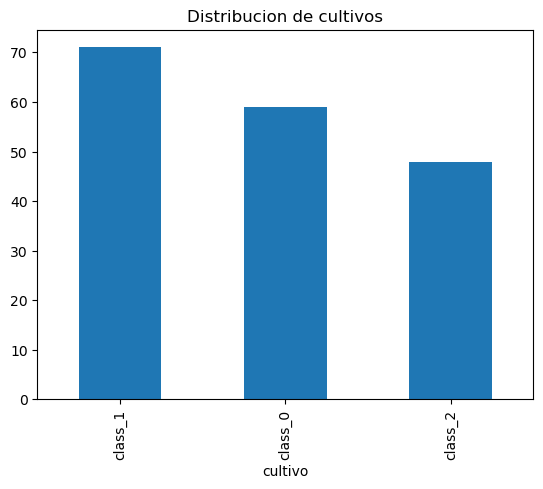

In [16]:
#Graficamos la distribucion
dfWine["cultivo"].value_counts().plot(
    kind = "bar"
)
plt.title("Distribucion de cultivos")
plt.show()


## Identificar variables predictoras y variables objetivos


In [17]:
#Variable predictora
X = dfWine.drop(columns = ["cultivo"])


In [18]:
print("Variables predictoras")
print(X.columns)


Variables predictoras
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


In [19]:
#Varible objetivo
y = dfWine["cultivo"]


In [20]:
print("Variable objetivo")
print(y.name)


Variable objetivo
cultivo


## Dividir los datos

80% para entrenamiento

20% para prueba


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.20, random_state= 42, stratify=y
)


In [22]:
print("X_train", X_train.shape)
print("X_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)


X_train (142, 13)
X_test (36, 13)
y_train (142,)
y_test (36,)


## Entrenamiento del modelo GaussianNB



In [23]:
modelo = GaussianNB()


In [24]:
modelo.fit(
    X_train, y_train
)


GaussianNB()

## Realizamos predicciones con las variables de Prueba


In [25]:
prediccion = modelo.predict(X_test)


In [26]:
print (prediccion[:10])


['class_0' 'class_2' 'class_0' 'class_1' 'class_1' 'class_0' 'class_0'
 'class_0' 'class_1' 'class_2']


In [27]:
#Comparación entre valores reales y valores predecibles
comparacion = pd.DataFrame({
    "cultivo real": y_test.values,
    "cultivo predicho": prediccion
})


In [28]:
comparacion.head(10)


,cultivo real,cultivo predicho
0,class_0,class_0
1,class_2,class_2
2,class_0,class_0
3,class_1,class_1
4,class_1,class_1
5,class_0,class_0
6,class_0,class_0
7,class_1,class_0
8,class_1,class_1
9,class_2,class_2


## Evaluación del modelo


In [29]:
accuracy = accuracy_score(y_test, prediccion)
print(f"accuracy/exactitud: {accuracy: .4f}")


accuracy/exactitud:  0.9722


In [30]:
## Matriz de confusion
cm = confusion_matrix(y_test, prediccion, labels=modelo.classes_)


In [31]:
cm_df = pd.DataFrame(
    cm,
    index= modelo.classes_,
    columns= modelo.classes_
)
cm_df


,class_0,class_1,class_2
class_0,12,0,0
class_1,1,13,0
class_2,0,0,10


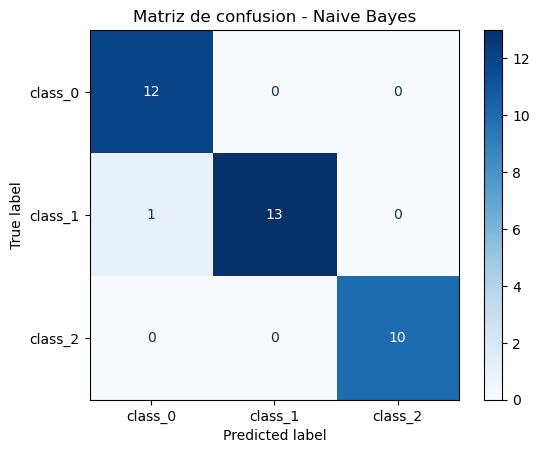

In [32]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
disp.plot(cmap="Blues")
plt.title("Matriz de confusion - Naive Bayes")
plt.show()


## Clasificacion report
Proporciona métricas que permitan evaluar el desempeño de cada clase: precission, recall, f1-score, support


In [33]:
print(classification_report(y_test, prediccion))


              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



## Importancia de las variables (Permutation Importance)

`GaussianNB` **no tiene un atributo `feature_importances_`** como sí lo tienen los modelos basados en árboles: no divide el espacio por variable, por lo que no existe una importancia "nativa" que extraer directamente del modelo.

Para obtener una medida de importancia válida para cualquier modelo (incluyendo Naive Bayes) se usa **Permutation Importance**: la idea es tomar el conjunto de prueba ya evaluado, revolver (permutar) aleatoriamente los valores de **una sola variable a la vez** manteniendo las demás intactas, y medir cuánto **cae el accuracy**. Si una variable es importante para el modelo, revolverla destruye su relación con la clase real y el accuracy baja notablemente; si una variable casi no la usa el modelo, revolverla apenas afecta el resultado.


In [34]:
perm = permutation_importance(
    modelo, X_test, y_test,
    n_repeats=30, random_state=42
)

importancia_df = pd.DataFrame({
    "variable": X.columns,
    "importancia_media": perm.importances_mean,
    "importancia_std": perm.importances_std
}).sort_values("importancia_media", ascending=False)

importancia_df


,variable,importancia_media,importancia_std
6,flavanoids,0.088889,0.041450
9,color_intensity,0.060185,0.037325
12,proline,0.056481,0.028222
11,od280/od315_of_diluted_wines,0.043519,0.037049
0,alcohol,0.022222,0.020787
10,hue,0.011111,0.031753
2,ash,0.000926,0.004986
4,magnesium,0.000000,0.000000
1,malic_acid,-0.004630,0.012594
7,nonflavanoid_phenols,-0.007407,0.015930


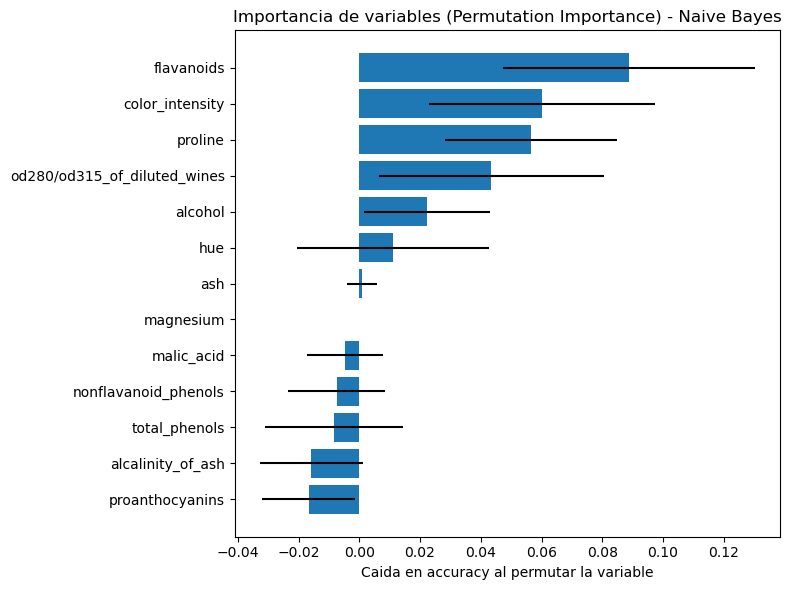

In [35]:
plt.figure(figsize=(8,6))
plt.barh(
    importancia_df["variable"],
    importancia_df["importancia_media"],
    xerr=importancia_df["importancia_std"]
)
plt.gca().invert_yaxis()
plt.xlabel("Caida en accuracy al permutar la variable")
plt.title("Importancia de variables (Permutation Importance) - Naive Bayes")
plt.tight_layout()
plt.show()


## Verificación del efecto del escalado

Se entrena una segunda versión del modelo, esta vez sobre los datos escalados con `StandardScaler` (ajustado solo con `X_train` para evitar fuga de información), para comprobar de forma empírica que GaussianNB no se beneficia del escalado.


In [36]:
scaler = StandardScaler()
X_train_escalado = scaler.fit_transform(X_train)
X_test_escalado = scaler.transform(X_test)

modelo_escalado = GaussianNB()
modelo_escalado.fit(X_train_escalado, y_train)
prediccion_escalada = modelo_escalado.predict(X_test_escalado)

accuracy_escalado = accuracy_score(y_test, prediccion_escalada)

print(f"Accuracy sin escalar: {accuracy: .4f}")
print(f"Accuracy escalado:    {accuracy_escalado: .4f}")
print("Predicciones identicas en ambos casos:", (prediccion == prediccion_escalada).all())


Accuracy sin escalar:  0.9722
Accuracy escalado:     0.9722
Predicciones identicas en ambos casos: True


## Implementación con datos nuevos

Se construye un vino **ficticio**, fuera del conjunto de entrenamiento y de prueba, con valores químicos plausibles (basados en los rangos típicos observados por clase con `dfWine.groupby("cultivo").mean()`). No se aplica ningún escalado adicional porque, como se demostró arriba, GaussianNB no lo requiere: el nuevo dato se pasa directamente al modelo en las mismas 13 columnas y unidades que `X_train`.


In [37]:
#Vino ficticio, con valores tipicos de la clase class_1
nuevo_vino = pd.DataFrame([{
    "alcohol": 12.3,
    "malic_acid": 1.9,
    "ash": 2.2,
    "alcalinity_of_ash": 20.0,
    "magnesium": 100.0,
    "total_phenols": 2.3,
    "flavanoids": 2.1,
    "nonflavanoid_phenols": 0.35,
    "proanthocyanins": 1.5,
    "color_intensity": 3.5,
    "hue": 1.05,
    "od280/od315_of_diluted_wines": 2.8,
    "proline": 520.0
}])
nuevo_vino


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,12.3,1.9,2.2,20.0,100.0,2.3,2.1,0.35,1.5,3.5,1.05,2.8,520.0


In [38]:
prediccion_nueva = modelo.predict(nuevo_vino)
probabilidades_nueva = modelo.predict_proba(nuevo_vino)

print("Cultivo predicho:", prediccion_nueva[0])
print()
print("Probabilidad por clase:")
for clase, prob in zip(modelo.classes_, probabilidades_nueva[0]):
    print(f"  {clase}: {prob:.6f}")


Cultivo predicho: class_1

Probabilidad por clase:
  class_0: 0.000004
  class_1: 0.999996
  class_2: 0.000000


## Conclusiones

**Resultado obtenido:** el modelo GaussianNB alcanzó un **accuracy de 0.9722** sobre el conjunto de prueba (35 de 36 vinos clasificados correctamente), lo que indica un desempeño alto para este problema de clasificación con tres clases.

**¿Dónde falló el modelo?** La matriz de confusión muestra un único error: un vino de `class_1` fue clasificado como `class_0` (precision de `class_0` = 0.92, recall de `class_1` = 0.93). El resto de los vinos de prueba fueron clasificados correctamente en las tres clases.

**El escalado no tuvo ningún efecto.** Entrenar el modelo con y sin `StandardScaler` produjo **exactamente las mismas predicciones y el mismo accuracy**. Esto confirma en la práctica lo que predice la teoría: GaussianNB estima media y varianza por variable de forma independiente, y una transformación afín (como estandarizar) no cambia cuál clase obtiene mayor probabilidad.

**Importancia de variables:** el permutation importance identificó a `flavanoids`, `color_intensity` y `proline` como las variables que más caída de accuracy provocan al ser permutadas, es decir, las que más información aportan al modelo para separar los tres cultivos. Varias variables (`magnesium`, `ash`, `proanthocyanins`) tuvieron importancia cercana a cero o incluso ligeramente negativa (ruido estadístico esperable con solo 36 registros de prueba), lo que sugiere que un subconjunto más pequeño de variables podría alcanzar un desempeño similar.

**Limitaciones — por qué no hay que sobreinterpretar el 0.9722:**
- El conjunto de prueba es pequeño (36 registros): un solo vino mal clasificado mueve el accuracy 2.8 puntos porcentuales, así que el resultado debe leerse con cautela y no como una medida perfectamente estable del desempeño real del modelo.
- El supuesto de independencia entre variables no se cumple realmente en este dataset (por ejemplo, `flavanoids` y `total_phenols` están correlacionados químicamente); el modelo funcionó bien a pesar de eso, pero no hay garantía de que ese comportamiento se sostenga en un dataset con variables más correlacionadas entre sí.
- No se validó formalmente el supuesto de normalidad por variable y por clase (por ejemplo con un histograma o una prueba de Shapiro-Wilk); si alguna variable está muy sesgada dentro de una clase, `GaussianNB` está modelando su distribución de forma incorrecta aunque el resultado final se vea bien.
- Para una evaluación más robusta, lo recomendable sería usar **validación cruzada** sobre el conjunto de entrenamiento en lugar de una sola partición train/test, ya que un solo split de 36 datos de prueba no es suficiente para concluir con total confianza qué tan bien generaliza el modelo.

**Aprendizaje técnico:** esta práctica mostró que Naive Bayes es un algoritmo simple, rápido y sorprendentemente competitivo cuando las variables aportan información discriminante razonable, aunque el supuesto de independencia no se cumpla estrictamente. Su salida probabilística (`predict_proba`) es una ventaja frente a modelos que solo entregan una etiqueta, ya que permite comunicar el nivel de confianza de cada predicción.
